<a href="https://colab.research.google.com/github/ihsanpostt/PCVK_Ganjil_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Transformasi Linear Brightness

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 40


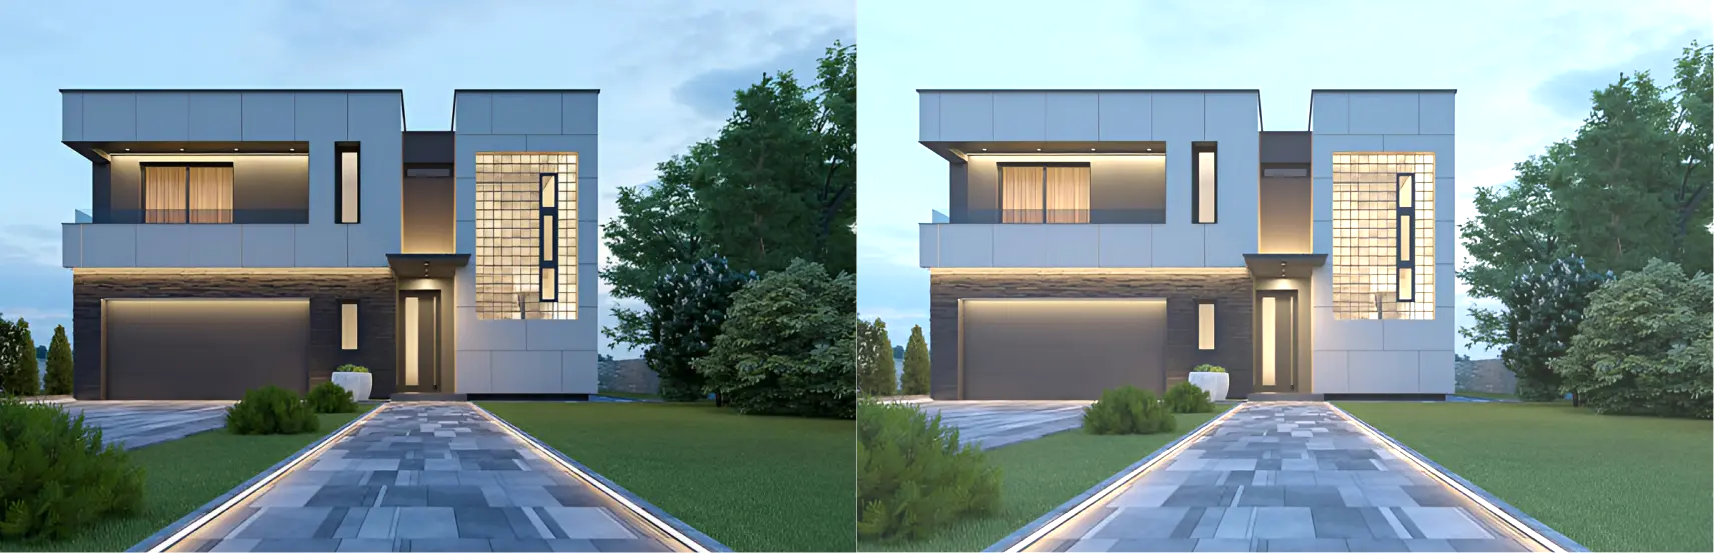

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    brightness = 0 # Nilai default jika terjadi error input

# Sesuaikan dengan file dan folder di drive Anda
# Pastikan path ini benar-benar ada di Google Drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/house.jpg')

# Cek apakah gambar berhasil diload
if original is None:
    print("Error: Gambar tidak ditemukan! Cek kembali path/jalur filenya.")
else:
    brightness_image = np.zeros(original.shape, original.dtype)

    # akses per piksel
    # np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            for c in range(original.shape[2]):
                # Catatan Penting: Kita perlu mengubah tipe data ke 'int' sementara
                # saat penjumlahan agar tidak terjadi overflow pada tipe data uint8 (0-255)
                hasil_tambah = int(original[y,x,c]) + brightness
                brightness_image[y,x,c] = np.clip(hasil_tambah, 0, 255)

    # cara simple tanpa for loop (bisa di-uncomment jika ingin mencoba cara cepat)
    # brightness_image = cv.convertScaleAbs(original, beta=brightness)

    # Gabungkan gambar asli dan gambar yang sudah diubah kecerahannya secara horizontal
    final_frame = cv.hconcat((original, brightness_image))

    # Tampilkan gambar di Colab
    cv2_imshow(final_frame)

--- TUGAS 1: INVERSE CITRA ---


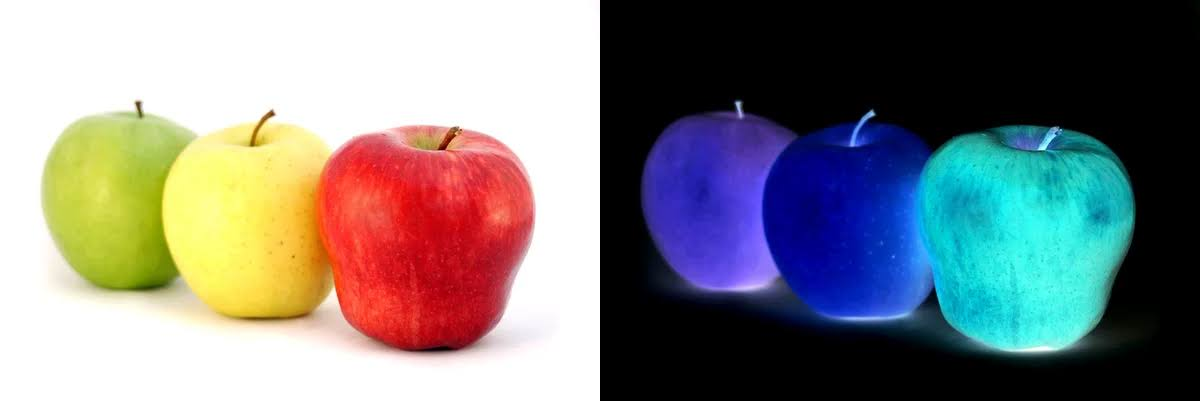

In [27]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print("--- TUGAS 1: INVERSE CITRA ---")
img_peppers = cv.imread('/content/drive/MyDrive/PCVK/buah.jpg')

if img_peppers is None:
    print("Tolong upload gambar")
else:
    inverse_image = 255 - img_peppers
    final_peppers = cv.hconcat((img_peppers, inverse_image))
    cv2_imshow(final_peppers)

 Mengubah kontras dan tingkat kecerahan citra 
---------------------------------------------
Masukkan tingkat kecerahan : 50
Masukkan kontras : 1.5


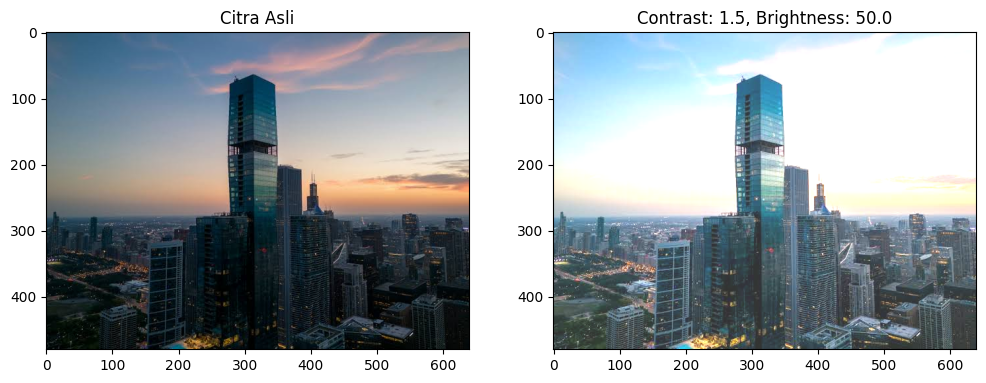

In [39]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print(' Mengubah kontras dan tingkat kecerahan citra ')
print('---------------------------------------------')

try:
    # Menggunakan float agar bisa memasukkan nilai desimal seperti 1.5
    brightness = float(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')
    brightness = 10.0
    contrast = 1.5

# 1. Load gambar (Sesuaikan path file di Google Drive Anda, misal landscape.jpg)
path_gambar = '/content/drive/MyDrive/PCVK/gedung.jpg'
original = cv.imread(path_gambar)

if original is None:
    print("Error: Gambar tidak ditemukan! Cek kembali path atau nama file Anda.")
else:
    # Konversi BGR dari OpenCV ke RGB untuk ditampilkan dengan Matplotlib
    original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    # 2. Proses Transformasi Kontras dan Kecerahan
    # Menggunakan fungsi bawaan OpenCV: cv.convertScaleAbs(image, alpha=kontras, beta=kecerahan)
    # alpha mengontrol kontras, beta mengontrol kecerahan
    adjusted = cv.convertScaleAbs(original_rgb, alpha=contrast, beta=brightness)

    # 3. Tampilkan hasil citra asli dan citra hasil penyesuaian berdampingan
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Citra Asli
    axes[0].imshow(original_rgb)
    axes[0].set_title('Citra Asli')

    # Citra Hasil Transformasi Kontras & Kecerahan
    axes[1].imshow(adjusted)
    axes[1].set_title(f'Contrast: {contrast}, Brightness: {brightness}')

    plt.show()

 Mengubah tingkat kecerahan citra dengan Transformasi Log 
---------------------------------------------------------
Masukkan nilai kecerahan: 50


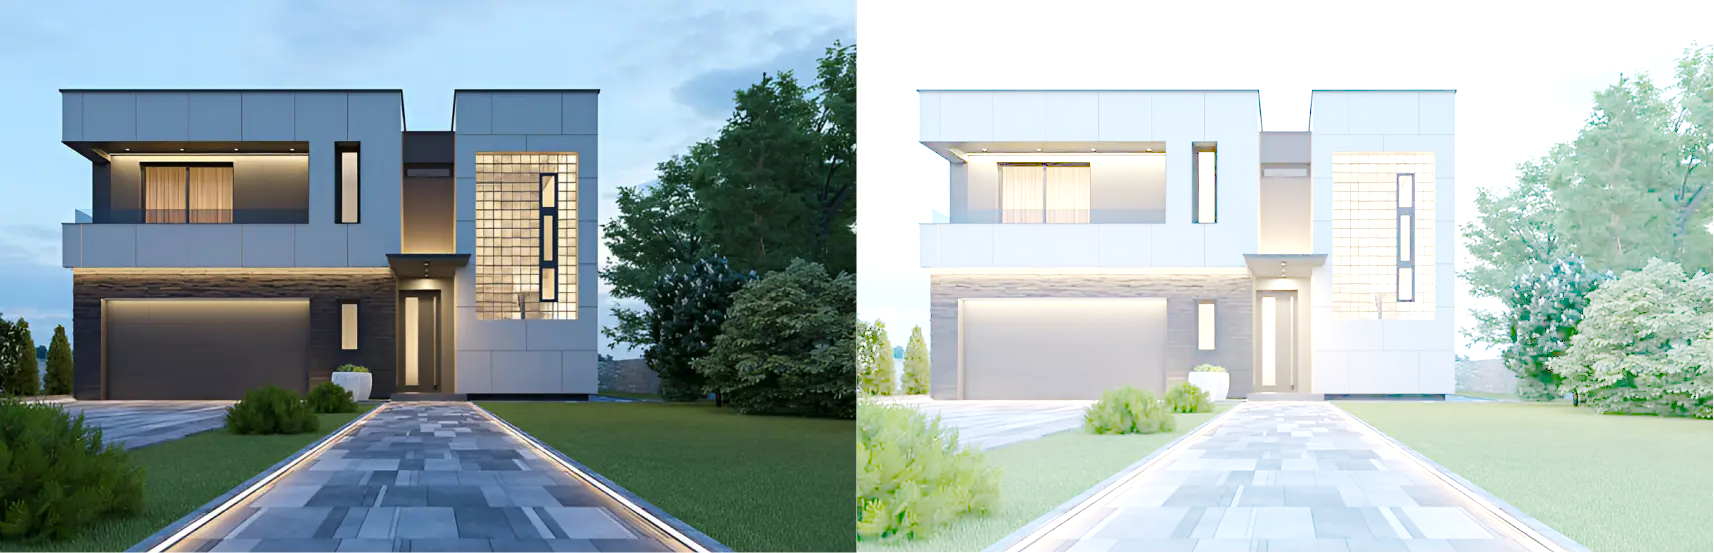

In [42]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra dengan Transformasi Log ')
print('---------------------------------------------------------')

try:
    c = float(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    c = 50.0

# Load gambar (sesuaikan path file Anda)
path_gambar = '/content/drive/MyDrive/PCVK/house.jpg'
original = cv.imread(path_gambar)

if original is None:
    print("Error: Gambar tidak ditemukan! Cek kembali path atau nama file Anda.")
else:
    # Proses Transformasi Logaritmik
    img_float = original.astype(float)
    log_image = c * np.log(1 + img_float)
    log_image = np.clip(log_image, 0, 255)
    log_image = log_image.astype(np.uint8)

    # Gabungkan gambar asli dan hasil transformasi log secara horizontal
    final_frame = cv.hconcat((original, log_image))

    # Tampilkan hasil persis seperti tampilan di modul (tanpa sumbu koordinat)
    cv2_imshow(final_frame)

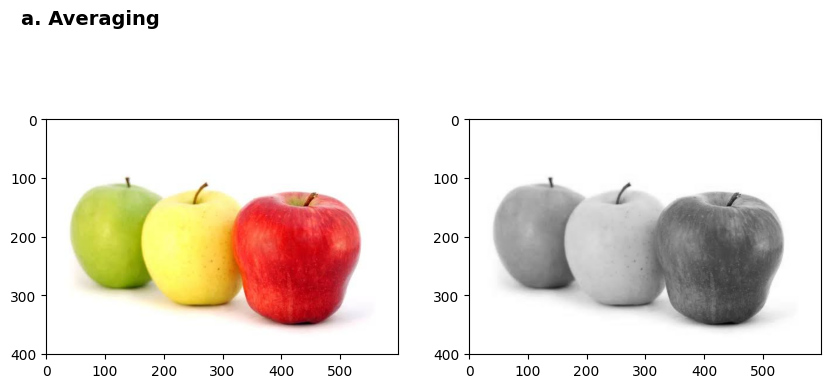

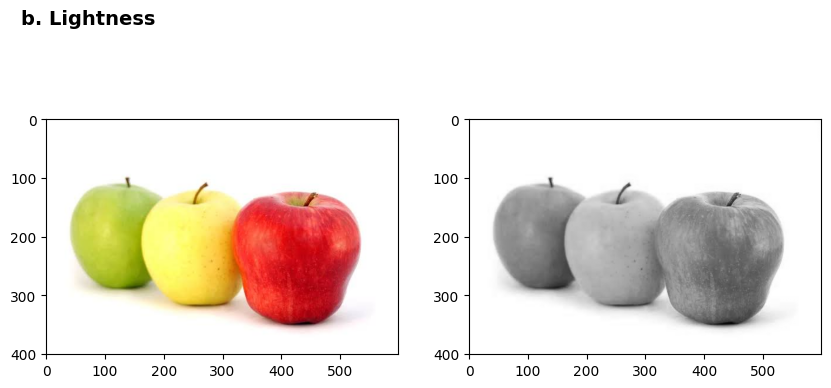

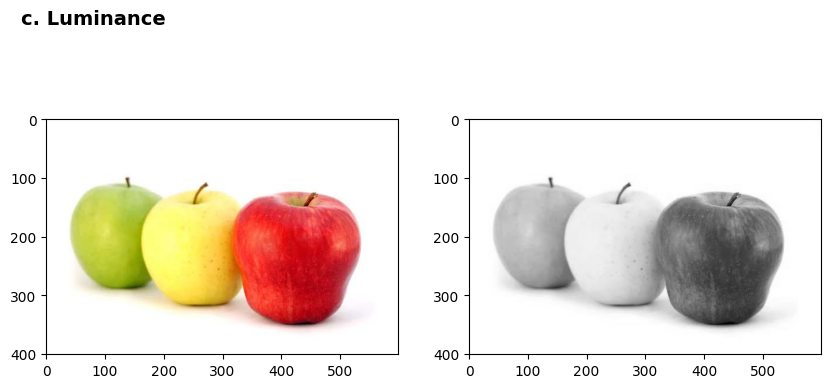

In [37]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load gambar (Pastikan path-nya sudah benar pakai .jpg!)
path_gambar = '/content/drive/MyDrive/PCVK/buah.jpg'
img_bgr = cv.imread(path_gambar)

if img_bgr is None:
    print("Error: Gambar tidak ditemukan! Cek kembali path filenya.")
else:
    # OpenCV membaca gambar dalam format BGR, kita ubah ke RGB untuk Matplotlib
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # Pisahkan channel warna R, G, dan B
    # Kita ubah tipenya ke float untuk menghindari error overflow saat perhitungan matematis
    R = img_rgb[:,:,0].astype(float)
    G = img_rgb[:,:,1].astype(float)
    B = img_rgb[:,:,2].astype(float)

    # ==========================================
    # a. Metode Averaging
    # ==========================================
    img_avg = (R + G + B) / 3.0
    img_avg = img_avg.astype(np.uint8) # Kembalikan ke format gambar (0-255)

    # ==========================================
    # b. Metode Lightness
    # ==========================================
    # Cari nilai maksimum dan minimum di setiap piksel dari ketiga channel
    max_rgb = np.max(img_rgb, axis=2).astype(float)
    min_rgb = np.min(img_rgb, axis=2).astype(float)

    img_lightness = (max_rgb + min_rgb) / 2.0
    img_lightness = img_lightness.astype(np.uint8)

    # ==========================================
    # c. Metode Luminance
    # ==========================================
    img_luminance = (0.299 * R) + (0.587 * G) + (0.114 * B)
    img_luminance = img_luminance.astype(np.uint8)

    # ==========================================
    # Plotting
    # ==========================================

    # Fungsi bantuan untuk plot agar kode lebih rapi
    def plot_side_by_side(img_asli, img_gray, judul):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Gambar Asli
        axes[0].imshow(img_asli)
        # Hapus judul pada gambar asli agar persis seperti di contoh soal

        # Gambar Grayscale
        axes[1].imshow(img_gray, cmap='gray', vmin=0, vmax=255)

        plt.suptitle(judul, fontsize=14, fontweight='bold', x=0.1, y=0.95, ha='left')
        plt.show()

    # Tampilkan hasil a. Averaging
    plot_side_by_side(img_rgb, img_avg, 'a. Averaging')

    # Tampilkan hasil b. Lightness
    plot_side_by_side(img_rgb, img_lightness, 'b. Lightness')

    # Tampilkan hasil c. Luminance (Jika diperlukan)
    plot_side_by_side(img_rgb, img_luminance, 'c. Luminance')

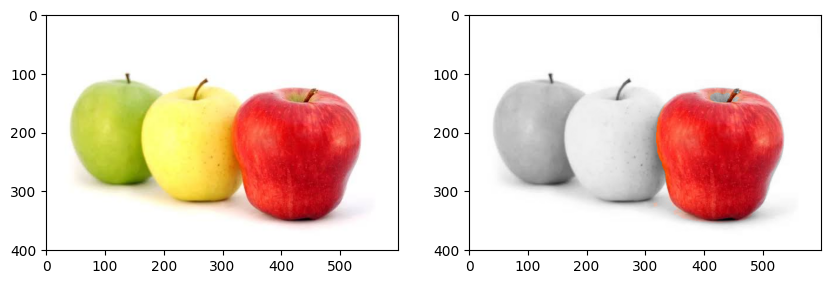

In [44]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load gambar (Pastikan path dan ekstensinya sudah benar, misal .jpg)
path_gambar = '/content/drive/MyDrive/PCVK/buah.jpg'
img_bgr = cv.imread(path_gambar)

if img_bgr is None:
    print("Error: Gambar tidak ditemukan! Cek kembali path atau nama file Anda.")
else:
    # Ubah BGR ke RGB untuk ditampilkan dengan Matplotlib
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # 2. Konversi citra dari RGB ke HSV untuk memudahkan deteksi warna
    img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

    # 3. Tentukan rentang warna merah dalam HSV
    # Warna merah di OpenCV terbagi menjadi dua rentang (karena melingkar di angka 0 dan 180)
    lower_red1 = np.array([0, 50, 50])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 50, 50])
    upper_red2 = np.array([180, 255, 255])

    # Buat mask (penaring) untuk warna merah
    mask1 = cv.inRange(img_hsv, lower_red1, upper_red1)
    mask2 = cv.inRange(img_hsv, lower_red2, upper_red2)
    red_mask = cv.bitwise_or(mask1, mask2)

    # 4. Buat versi grayscale dari gambar asli menggunakan metode Luminance
    R = img_rgb[:,:,0].astype(float)
    G = img_rgb[:,:,1].astype(float)
    B = img_rgb[:,:,2].astype(float)
    gray_img = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

    # Ubah grayscale 2D menjadi 3-channel (RGB) agar bisa digabungkan
    gray_3ch = np.stack([gray_img, gray_img, gray_img], axis=-1)

    # 5. Pisahkan bagian merah (tetap berwarna) dan bagian lain (jadi grayscale)
    # Gunakan mask untuk mengambil area merah dari gambar asli
    result_red = cv.bitwise_and(img_rgb, img_rgb, mask=red_mask)

    # Invers mask untuk mengambil area selain merah
    inv_mask = cv.bitwise_not(red_mask)
    result_gray = cv.bitwise_and(gray_3ch, gray_3ch, mask=inv_mask)

    # Gabungkan keduanya
    final_output = cv.add(result_red, result_gray)

    # 6. Tampilkan hasil berdampingan dengan sumbu koordinat
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Gambar Asli
    axes[0].imshow(img_rgb)

    # Gambar Hasil Filter (Hanya Merah yang Berwarna)
    axes[1].imshow(final_output)

    plt.show()

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 2.5


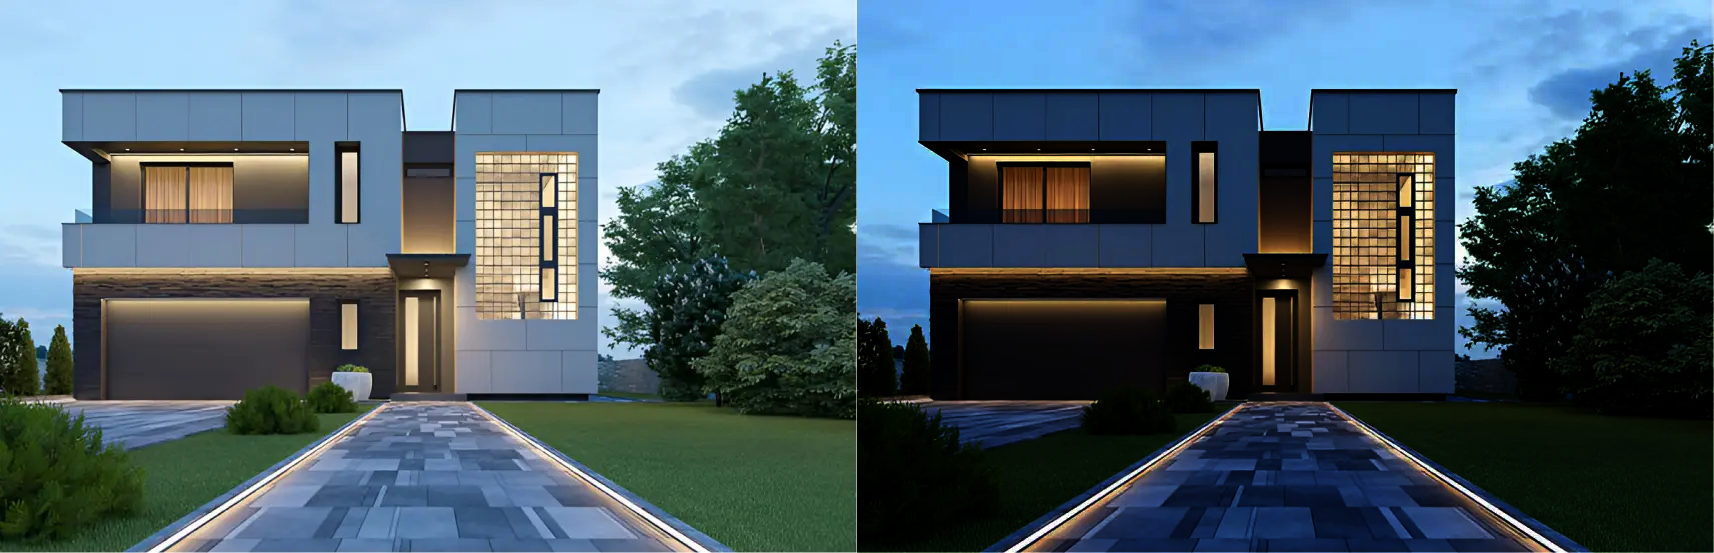

In [46]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Gamma Correction pada citra ')
print('----------------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = 0.5

path_gambar = '/content/drive/MyDrive/PCVK/house.jpg'
original = cv.imread(path_gambar)

if original is None:
    print("Error: Gambar tidak ditemukan! Cek kembali path atau nama file Anda.")
else:
    normalized = original / 255.0
    gamma_corrected = np.power(normalized, gamma)
    gamma_corrected = (gamma_corrected * 255.0).astype(np.uint8)

    final_frame = cv.hconcat((original, gamma_corrected))
    cv2_imshow(final_frame)

 Simulasi Image Depth / Kuantisasi Citra 
-----------------------------------------
Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


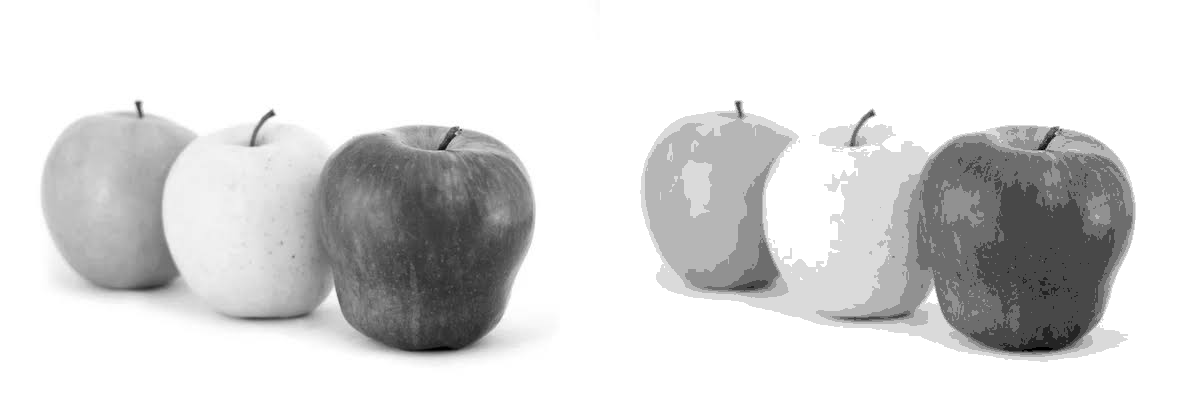

In [48]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Simulasi Image Depth / Kuantisasi Citra ')
print('-----------------------------------------')

try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
    if bit_depth < 1 or bit_depth > 8:
        print('Error: Masukkan angka antara 1 sampai 8!')
        bit_depth = 3
except ValueError:
    print('Error, not a number')
    bit_depth = 3

# Load gambar dalam mode Grayscale (sesuaikan path file Anda)
path_gambar = '/content/drive/MyDrive/PCVK/buah.jpg'
original = cv.imread(path_gambar, cv.IMREAD_GRAYSCALE)

if original is None:
    print("Error: Gambar tidak ditemukan! Cek kembali path atau nama file Anda.")
else:
    max_val = 2 ** bit_depth - 1
    level = 255 / max_val

    depth_image = np.zeros(original.shape, original.dtype)

    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            depth_image[y, x] = np.round(original[y, x] / level) * level

    print(f'Bit depth awal  : 8 bit')
    print(f'Bit depth tujuan: {bit_depth} bit')
    print(f'Jumlah level    : {int(max_val + 1)}')

    # Gabungkan gambar asli 8-bit dan hasil depth image secara horizontal
    final_frame = cv.hconcat((original, depth_image))
    cv2_imshow(final_frame)

In [36]:
import cv2 as cv
import numpy as np
import glob
import matplotlib.pyplot as plt
from math import log10, sqrt

# 1. Load citra asli (referensi tanpa noise)
# Sesuaikan path gambar asli Anda
path_asli = '/content/drive/MyDrive/PCVK/planet.jpg'
img_asli = cv.imread(path_asli, cv.IMREAD_GRAYSCALE)

if img_asli is None:
    print("Error: Citra asli galaxy.jpg tidak ditemukan! Periksa kembali path-nya.")
else:
    # 2. Load kumpulan citra dengan Gaussian Noise menggunakan glob
    # Sesuaikan path folder noises Anda
    folder_noises = '/content/drive/MyDrive/PCVK/noises/planet.jpg'
    cv_img = []

    for img_path in sorted(glob.glob(folder_noises)):
        n = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
        if n is not None:
            cv_img.append(n)

    print(f"Total citra noise yang berhasil dimuat: {len(cv_img)} citra.")

    if len(cv_img) == 0:
        print("Error: Tidak ada citra di dalam folder noises!")
    else:
        # Fungsi untuk menghitung nilai PSNR
        def hitung_psnr(asli, hasil):
            mse = np.mean((asli.astype(float) - hasil.astype(float)) ** 2)
            if mse == 0:
                return float('inf')
            max_pixel = 255.0
            psnr = 20 * log10(max_pixel / sqrt(mse))
            return psnr

        # Daftar jumlah citra yang akan diuji sesuai tabel tugas (10, 20, 40, 80, 100)
        jumlah_list = [10, 20, 40, 80, 100]

        print("\n--- HASIL EKSPERIMEN AVERAGE DENOISING ---")

        for jml in jumlah_list:
            if jml > len(cv_img):
                print(f"Peringatan: Jumlah citra yang diminta ({jml}) melebihi total file yang ada ({len(cv_img)}).")
                continue

            # Ambil sebanyak 'jml' citra lalu lakukan averaging (penjumlahan dan dirata-rata)
            tumpukan = np.zeros_like(img_asli, dtype=float)
            for i in range(jml):
                tumpukan += cv_img[i].astype(float)

            img_avg = (tumpukan / jml).astype(np.uint8)

            # Hitung nilai PSNR
            nilai_psnr = hitung_psnr(img_asli, img_avg)

            print(f"Jumlah Citra: {jml:3d} | Nilai PSNR: {nilai_psnr:.2f} dB")

            # Tampilkan hasil gambar per pengujian (opsional, untuk melihat perubahan visual)
            plt.figure(figsize=(4, 4))
            plt.imshow(img_avg, cmap='gray', vmin=0, vmax=255)
            plt.title(f'Averaging {jml} Citra (PSNR: {nilai_psnr:.2f} dB)')
            plt.axis('off')
            plt.show()

Total citra noise yang berhasil dimuat: 0 citra.
Error: Tidak ada citra di dalam folder noises!
